# Activité 2 : Débruitage/réhaussement de la parole

In [2]:
import os 
import matplotlib.pyplot as plt #pour afficher des points
import numpy as np #different fonction math
import math
import librosa
import soundfile as sf  #write

##  1. Recuperation du signal 

In [3]:
file = "test_seg.wav"
filenameroot = '.'.join(file.split('.')[:-1]) #enlever l'extension
folder_path = "./"

signal, samplingrate = librosa.load(os.path.join(folder_path, file))
print("Sampling frequency : "+ str(samplingrate) + " Hz")
print("Taille du signal :  "+ str(len(signal)) +" (echantillons) ---> " + str(len(signal) * 1000 // samplingrate) + " ms")



Sampling frequency : 22050 Hz
Taille du signal :  53010 (echantillons) ---> 2404 ms


In [4]:
# remettre le signal sur 16 bits (entre -32K +32K)
signal = 2**15*signal 
# enlever la composante continue
print("Moyenne du signal :" + str(np.mean(signal)))
signal = signal-np.mean(signal)
print("Moyenne du signal (sans la composante continue) :" + str(np.mean(signal)))

Moyenne du signal :22.186852
Moyenne du signal (sans la composante continue) :-2.5367413e-05


In [6]:
def displaysignal(signal, freqsampling, sizesignal, alone, ax=None):
    '''
        sizesignal is the size of visible signal
    '''
    
    #si le graphique est seul on crée un figure
    if alone :
        fig, ax = plt.subplots(1,1, figsize=(10,3), dpi=80)
        
    ax.plot(signal)
    ax.set_xlim(0, sizesignal)
    pasticks_samples=int(sizesignal/10) #pour avoir 10 ticks
    #version avec juste les ticks en echantillons
    ax.set_xticks(np.arange(0,sizesignal,step=pasticks_samples))
    ax.set_xlabel('temps (echt)') 
    ymin, ymax = ax.set_ylim()
    yborne = max(np.abs(ymin),np.abs(ymax))
    ax.set_yticks([-1*yborne, 0, yborne])

    if alone :
        plt.show()


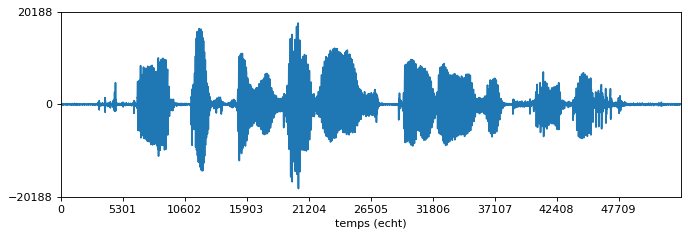

In [7]:
signalsize = len(signal)
displaysignal(signal, samplingrate, signalsize, alone=True)

## 2. Principe d’OverLap and Add et Fourier

In [8]:
hopsize_ms = 8  #m
windowsize_ms = 32  #N
hopsize_echt = (int)(hopsize_ms*samplingrate/1000)
windowsize_echt = (int)(windowsize_ms*samplingrate/1000)
fftsize = 1024
print("Hop size : "+str(hopsize_ms)+" ms --> "+ str(hopsize_echt)+ " (echantillons)")
print("Window size : "+str(windowsize_ms)+" ms --> "+ str(windowsize_echt)+ " (echantillons)")
print("FFT size : " + str(fftsize))

SPECTRE = librosa.stft(signal, n_fft=fftsize, hop_length=hopsize_echt, win_length=windowsize_echt, window='hamming')
print("shape SPECTRE : "+ str(SPECTRE.shape))

Hop size : 8 ms --> 176 (echantillons)
Window size : 32 ms --> 705 (echantillons)
FFT size : 1024
shape SPECTRE : (513, 302)


In [15]:
#librosa.istft(stft_matrix, *, hop_length=None, win_length=None, n_fft=None, window='hann', center=True, dtype=None, length=None, out=None)
#on a besoin de lenght
signal_reconstr = librosa.istft(SPECTRE, hop_length=hopsize_echt, win_length=windowsize_echt, n_fft=fftsize, window='hamming')

signal_reconstr_norm = signal_reconstr/2**15 #-1 +1

sf.write(filenameroot + "_reconstruction.wav", signal_reconstr_norm,samplingrate)
print("File Wav obtained: "+filenameroot+"_resultat_reconstruction.wav")

File Wav obtained: test_seg_resultat_reconstruction.wav


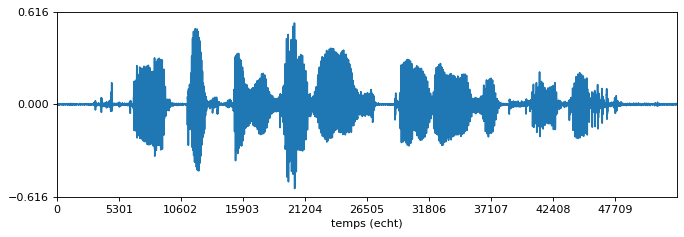

In [16]:
displaysignal(signal_reconstr_norm, samplingrate, signalsize, alone=True)

## 3. Spectre d'amplitude et Spectre de phase

In [17]:
SPECTRE_MAGN, SPECTRE_PHASE  = librosa.magphase(SPECTRE, power=1)

## affichage spectrogramme

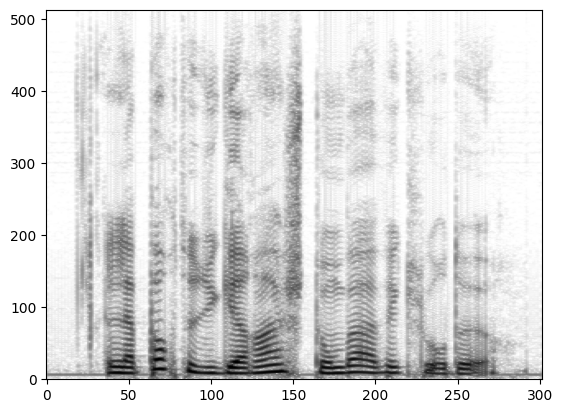

In [18]:
# SPECTRE_MAGN_T = SPECTRE_MAGN.transpose()
# print("shape SPECTRE_MAGN (transposed):" + str(SPECTRE_MAGN_T.shape))

#pour spectrogramme 
# SPECTRE_MAGN_T = np.array([20*np.log10(spectre) for spectre in SPECTRE_MAGN_T])

SPECTRE_MAGN_DB = np.array([20*np.log10(spectre) for spectre in SPECTRE_MAGN])
plt.imshow(SPECTRE_MAGN_DB, origin='lower', aspect='auto',cmap='Greys', vmin=40, vmax= 120)
# plt.show()
# plt.plot(SPECTRE_MAGN_DB.transpose()[100])


## Debruitage
 Travailler sur SPECTRE_MAGN transposée
. Estimation + soustraction
. Puis ne pas oublier de re-transposer avec l'étape de reconstruction

## Reconstruction : Spectre d'amplitude et Spectre de phase

In [20]:
SPECTRE_Reconstruct = SPECTRE_MAGN * SPECTRE_PHASE

## 5. Reconstruction : ISTFT

In [22]:
#librosa.istft(stft_matrix, *, hop_length=None, win_length=None, n_fft=None, window='hann', center=True, dtype=None, length=None, out=None)
#on a besoin de lenght
signal_reconstr = librosa.istft(SPECTRE_Reconstruct, hop_length=hopsize_echt, win_length=windowsize_echt, n_fft=fftsize, window='hamming')

signal_reconstr_norm = signal_reconstr/2**15 #-1 +1

sf.write(filenameroot + "_reconstruction.wav", signal_reconstr_norm,samplingrate)
print("File Wav obtained: "+filenameroot+"_resultat_reconstruction.wav")

File Wav obtained: test_seg_resultat_reconstruction.wav


## 6. Estimation du spectre d’amplitude du bruit 

In [23]:
# Transposer pour avoir (nb_trames, nb_freq)
SPECTRE_MAGN_T = SPECTRE_MAGN.transpose()
# Moyenne sur les 8 premiers spectres (colonne par colonne)
bruit_estime = np.mean(SPECTRE_MAGN_T[:8], axis=0)
print("Bruit estimé shape :", bruit_estime.shape)

Bruit estimé shape : (513,)


## 7. Debruitage par soustraction spectrale 

In [29]:
def soustractionSpectrale(X,B, alpha=2, beta=1, gamma=0) :

    diff = ( (X**alpha) - (beta*B**alpha) )
    res = np.where(diff > 0, diff **(1/alpha), gamma * B)

    return res

In [31]:
SPECTRE_MAGN_DEBRUITE_T = soustractionSpectrale(SPECTRE_MAGN_T, bruit_estime, alpha=2, beta=1, gamma=0)

# Retransposer pour revenir au format librosa (nb_freq, nb_trames)
SPECTRE_MAGN_DEBRUITE = SPECTRE_MAGN_DEBRUITE_T.transpose()

# Recombiner avec la phase
SPECTRE_Reconstruct_debruite = SPECTRE_MAGN_DEBRUITE * SPECTRE_PHASE

# Reconstruire le signal
signal_debruite = librosa.istft(SPECTRE_Reconstruct_debruite, hop_length=hopsize_echt, win_length=windowsize_echt, n_fft=fftsize, window='hamming')
signal_debruite_norm = signal_debruite / 2**15
sf.write(filenameroot + "_debruite.wav", signal_debruite_norm, samplingrate)
print("Signal débruité écrit.")


Signal débruité écrit.


/tmp/ipykernel_7262/2975651391.py:4: RuntimeWarning: invalid value encountered in sqrt
  res = np.where(diff > 0, diff **(1/alpha), gamma * B)


In [40]:
import itertools
import os

# === CONFIGURATION ===
fichiers_bruites = [
    "./Fichiers_tests/test1_avec_bruit_0dB.wav",   # adapte les noms à tes fichiers réels


]
alphas = [1, 2]
betas  = [1, 5, 10, 30]
gammas = [0, 0.01, 0.1, 0.25]

os.makedirs("resultats", exist_ok=True)
os.makedirs("spectrogrammes", exist_ok=True)

for fichier in fichiers_bruites:
    snr_label = fichier.replace(".wav","").split("_")[-1]  # ex: "10dB"

    sig, sr = librosa.load(fichier)
    sig = 2**15 * sig
    sig -= np.mean(sig)

    SPECTRE_b = librosa.stft(sig, n_fft=fftsize, hop_length=hopsize_echt,
                              win_length=windowsize_echt, window='hamming')
    MAG_b, PHA_b = librosa.magphase(SPECTRE_b, power=1)
    MAG_b_T = MAG_b.transpose()
    bruit_est = np.mean(MAG_b_T[:8], axis=0)

    for a, b, g in itertools.product(alphas, betas, gammas):
        nom_base = f"snr{snr_label}_a{a}_b{b}_g{g}"

        # --- Débruitage ---
        deb_T = soustractionSpectrale(MAG_b_T, bruit_est, alpha=a, beta=b, gamma=g)
        deb   = deb_T.transpose()
        spectre_final = deb * PHA_b
        sig_out = librosa.istft(spectre_final, hop_length=hopsize_echt,
                                win_length=windowsize_echt, n_fft=fftsize, window='hamming')
        sf.write(f"resultats/{nom_base}.wav", sig_out / 2**15, sr)

        # --- Spectrogramme ---
        plt.figure(figsize=(8, 3))
        plt.imshow(20 * np.log10(deb + 1e-10), origin='lower',
                   aspect='auto', cmap='magma')
        plt.colorbar(label='dB')
        plt.title(f"SNR={snr_label}  α={a}  β={b}  γ={g}")
        plt.xlabel("Trames")
        plt.ylabel("Fréquences")
        plt.tight_layout()
        plt.savefig(f"spectrogrammes/{nom_base}.png", dpi=100)
        plt.close()

print("Terminé — fichiers dans resultats/ et spectrogrammes/")

/tmp/ipykernel_7262/2975651391.py:4: RuntimeWarning: invalid value encountered in sqrt
  res = np.where(diff > 0, diff **(1/alpha), gamma * B)


Terminé — fichiers dans resultats/ et spectrogrammes/
